## Outlier
An outlier is an observation in a given dataset that lies far from the rest of the observations.
for ex: while measuring the body temp , there was an entry of 988 degrees celsius.
        it should have been 98.8 instead of 988.(Data Entry Error)
        Another ex is while measuring the weights of high school students , there was an entry          with a weight of 1234 which is unlikely.

ex: consider a small dataset sample=[15,101,18,7,13,16,11,21,5,15,10,9].
    '101' is an outlier.
    with outlier           without outlier
                            mean:12.72
                            median: 13.0
                            mode:15
                            variance:21.28
                            std dev:4.61
                            
    mean: 20.08
    median: 14.0
    mode:15
    variance:614.74
    std dev:24.79

Reason for an outlier exists in dataset:
    1) Data Entry Error.
    2) Variability in the dataset.
    The range of outliers depends on buisness problems and can change from case to case.

Every time outliers r not dangerous
- let's say if we have age data , we get a person age 300 , then it is absurd so we have to remove it.
- otherwise , lets say if we've to check the error in credit card transactions. then we've to keep record of outliers.
-so keeping or  not keeping outliers depends on pblm statement.

how to treat an outlier?
(i) Trimming
(ii)Capping(if we've range of 0 to 25 then values less than 0 becomes 0 and greater than 25 becomes 25

Various ways of finding outlier
1. Using z score ( if we've nrml distri then we use z score )
2. Using Interquartile range(if skewed distri)
3. Using percentile(if we've any other distri)
4. Nrml distribution is a bell shaped curve where center lies at the mean and most of the data is clustured arnd centre of data.
6. The values that lies outside mu - 3 sigma and mu + 3 sigma are outliers

   Executing these below on dataset

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data=pd.read_csv("scholarship.csv")

In [5]:
df=data.copy()

In [7]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
998,86.2,46,1


C:\Users\mansi\AppData\Local\Temp\ipykernel_5360\2145191025.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["semester_percentage"])
C:\Users\mansi\AppData\Local\Temp\ipykernel_5360\2145191025.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(["scholarship_exam_marks"])


ValueError: could not convert string to float: 'scholarship_exam_marks'

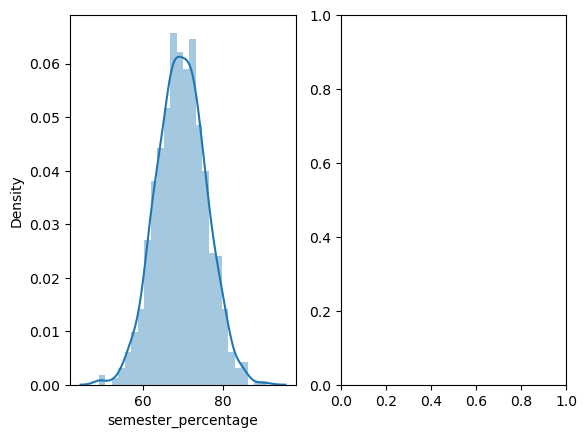

In [9]:
plt.subplot(1,2,1)
sns.distplot(df["semester_percentage"])
plt.subplot(1,2,2)
sns.distplot(["scholarship_exam_marks"])
plt.show()

In [17]:
mean=df["semester_percentage"].mean()
std=df["semester_percentage"].std()

In [19]:
print(mean ,"," , std)

69.6124 , 6.158978751323897


In [21]:
Highest_allowed = mean + 3*std
Lowest_allowed = mean - 3*std

In [23]:
print(Highest_allowed , " ," , Lowest_allowed)

88.08933625397168  , 51.13546374602831


In [25]:
df[(df["semester_percentage"]<Lowest_allowed) | (df["semester_percentage"]>Highest_allowed)]
## these r the outliers

,semester_percentage,scholarship_exam_marks,got_scholarship
485,49.2,44,1
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
999,49.0,10,1


In [27]:
## values without an oulier
df[(df["semester_percentage"]>Lowest_allowed) & (df["semester_percentage"]<Highest_allowed)]
## This is calles trimming

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
991,70.4,57,0
992,62.6,12,0
993,67.3,21,1
994,64.8,63,0


In [ ]:
##finding ouliers using z score

In [33]:
df["z_score"]=(df["semester_percentage"]-df["semester_percentage"].mean())/df["semester_percentage"].std()

In [35]:
df.head()
## we've coverted our nrml distri into std nrml distri

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371


In [39]:
df[(df["z_score"]<-3) | (df["z_score"]>3)]
## these r the outliers and u can check from above also  

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


In [41]:
## Trimming 
df[(df["z_score"]>-3) & (df["z_score"]<3)]
## dataset without outliers

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
991,70.4,57,0,0.127878
992,62.6,12,0,-1.138565
993,67.3,21,1,-0.375452
994,64.8,63,0,-0.781363


In [ ]:
## These rows which r removed cz of outliers have imp info so i don't wnt to trim those, so we r going to make 
## capping on these rows

# Capping

In [ ]:
##np.where(condition,x,y)
## if condi gets satisfied then will got with x otherwise with y 

In [43]:
upper_limit=mean+3*std
lower_limit=mean-3*std

In [45]:
df["semester_percentage"]=np.where(df["semester_percentage"]>upper_limit,upper_limit,
                                   np.where(df["semester_percentage"]<lower_limit,lower_limit
                                           , df["semester_percentage"]))

In [47]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.900000,26,1,0.371425
1,74.600000,38,1,0.809810
2,75.400000,40,1,0.939701
3,64.200000,8,1,-0.878782
4,72.300000,17,0,0.436371
...,...,...,...,...
995,88.089336,44,1,3.099150
996,88.089336,65,1,3.505062
997,51.135464,34,0,-3.362960
998,86.200000,46,1,2.693239


In [ ]:
##checking capping works or not

In [51]:
df[(df["semester_percentage"]<Lowest_allowed) | (df["semester_percentage"]>Highest_allowed)]
## we r not getting any outlier here cz we r making value capping on those 

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
